# N1 · R1-zero 式 GRPO 训练 (Countdown 任务)

> 复用 `src/r1_zero_track_a.py` + `grpo_minimal.py` · R1-zero 用 GRPO (组相对优势) + 可验证奖励 (RLVR)
> 在 Countdown (用数字凑目标) 上训练, 看 reward 随训练上升 (涌现推理)。(mock 动态)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, torch
import r1_zero_track_a as r1
import grpo_minimal as grpo
import random
print('reasoning-r1 src 就绪')

reasoning-r1 src 就绪


## 1. GRPO 的核心: 组相对优势 (无需 critic)

In [2]:
# GRPO: 一个 prompt 采 k 个回答, 用组内相对 reward 当优势 (省掉 value model)
rewards = torch.tensor([0.2, 0.9, 0.1, 0.5, 0.8, 0.0, 0.7, 0.3])
adv = grpo.compute_group_advantage(rewards, k=8)
print('组内 8 个回答 reward:', rewards.tolist())
print('组相对优势 (减组均值/除组标准差):', [round(a,2) for a in adv.tolist()])
print('→ 高于组均值的回答得正优势 (被强化), 低于的负优势 (被抑制)。无需单独 critic (GRPO 省 value model)。')

组内 8 个回答 reward: [0.20000000298023224, 0.8999999761581421, 0.10000000149011612, 0.5, 0.800000011920929, 0.0, 0.699999988079071, 0.30000001192092896]
组相对优势 (减组均值/除组标准差): [-0.7, 1.37, -1.0, 0.19, 1.07, -1.3, 0.78, -0.41]
→ 高于组均值的回答得正优势 (被强化), 低于的负优势 (被抑制)。无需单独 critic (GRPO 省 value model)。


## 2. Countdown 任务 + 可验证奖励 (RLVR) 训练曲线

Countdown 样例: 用 [4, 1, 9] 凑出 14
Track A — GPT-2-M Countdown-3 GRPO mock
  steps=200, k=8
  step    0: mean_R=0.00 adv_std=0.000
  step   20: mean_R=0.00 adv_std=0.000
  step   40: mean_R=0.12 adv_std=1.000
  step   60: mean_R=0.00 adv_std=0.000
  step   80: mean_R=0.00 adv_std=0.000
  step  100: mean_R=0.12 adv_std=1.000
  step  120: mean_R=0.12 adv_std=1.000
  step  140: mean_R=0.50 adv_std=1.000
  step  160: mean_R=0.25 adv_std=1.000
  step  180: mean_R=0.50 adv_std=1.000

  early avg reward = 0.044
  late  avg reward = 0.225
  Δ = +18.1pp


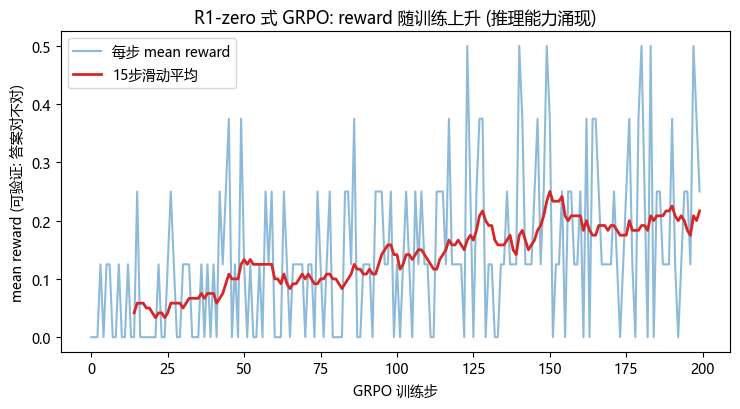

→ reward 从 0.04 升到 0.23 (RLVR: 用"答案可验证"当奖励, GRPO 优化)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
rng = random.Random(42)
nums, target = r1.gen_countdown_problem(rng)
print(f'Countdown 样例: 用 {nums} 凑出 {target}')
hist = r1.train_track_a(total_steps=200, k=8)
rew = [h['mean_reward'] for h in hist]
plt.figure(figsize=(7.5,4.2))
plt.plot(rew, alpha=0.5, label='每步 mean reward')
# 滑动平均
w=15; ma=np.convolve(rew, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(rew)), ma, 'C3', lw=2, label=f'{w}步滑动平均')
plt.xlabel('GRPO 训练步'); plt.ylabel('mean reward (可验证: 答案对不对)'); plt.legend()
plt.title('R1-zero 式 GRPO: reward 随训练上升 (推理能力涌现)'); plt.tight_layout(); plt.show()
print(f'→ reward 从 {np.mean(rew[:20]):.2f} 升到 {np.mean(rew[-20:]):.2f} (RLVR: 用"答案可验证"当奖励, GRPO 优化)。')

> 本专题其余 src (`r1_zero_track_b`/`reinforce_pp`/`rloo_minimal`/`grpo_minimal`) 是 R1 复现的不同 RL 算法。